c:\Users\cayez\Documents\DONNEES_SIMON\git\Workshop_nino



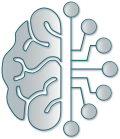

**Start at:** Tuesday 30 September 2025, 09:47:59  
**Hostname:** insa-09521 (Windows)

<p style="text-align: center"><img width="800px" src="./config/svg/pyPhysChemBanner.svg" style="margin-left:auto; margin-right:auto"/></p>

In [1]:
import os
import sys

print(os.getcwd())
cwd0 = './config/'
sys.path.append(cwd0)

import visualID_Eng as vID
from visualID_Eng import fg,bg,hl,color
vID.init(cwd0)

import tools4pyPhysChem as t4pPC

#cancel the "last show-up" behaviour of Jupyter notebooks
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all"

__author__ = "Simon Cayez, LPCNO / Département Génie Physique (INSA Toulouse, France)"

<h2 style="text-align: center;">
  <b><u>Introduction to Image Processing in Python</u>:<br></b>
</h2>

## 1- Numpy Library basics

NumPy is a library designed for manipulating multidimensional arrays.  
It is an essential tool for data science and research. NumPy enables you to perform complex mathematical operations, data manipulations, and logical operations efficiently and with a clear syntax.  
It forms the foundation of many other scientific Python libraries.  
Because NumPy is written in C, it can handle complex operations on large amounts of data much faster than pure Python code.


### 1-1-  Dimension and shape

#### 1-1-1 Read dimension and shape

- **shape** returns a tuple indicating the size of the array along each dimension.  
- **ndim** returns the number of dimensions of the array.

In [2]:
import numpy as np

# --- 1D array ---
array_1d = np.array([1, 2, 3])
print("1D array:\n", array_1d)
print(f"  ndim  : {array_1d.ndim} (number of dimensions)")
print(f"  shape : {array_1d.shape} (size along each dimension)")
print("-" * 40)

# --- 2D array ---
array_2d = np.array([[1, 2, 3],
                     [4, 5, 6]])
print("2D array:\n", array_2d)
print(f"  ndim  : {array_2d.ndim}")
print(f"  shape : {array_2d.shape}")
print("-" * 40)

# --- 3D array ---
array_3d = np.array([
    [[1, 2], [3, 4]],
    [[5, 6], [7, 8]]
])
print("3D array:\n", array_3d)
print(f"  ndim  : {array_3d.ndim}")
print(f"  shape : {array_3d.shape}")

1D array:
 [1 2 3]
  ndim  : 1 (number of dimensions)
  shape : (3,) (size along each dimension)
----------------------------------------
2D array:
 [[1 2 3]
 [4 5 6]]
  ndim  : 2
  shape : (2, 3)
----------------------------------------
3D array:
 [[[1 2]
  [3 4]]

 [[5 6]
  [7 8]]]
  ndim  : 3
  shape : (2, 2, 2)


#### 1-1-2- Change dimension and shape

- Reshape  

We may sometimes need to change the shape of an array without altering its data, for example to use tools that expect NumPy arrays with specific dimensions as input.
`np.reshape` will create a new arry with the specified shape.

In [3]:
array_1 = np.array([1, 2, 3, 4, 5, 6])
array_2 = np.reshape(array_1, (2, 3))  # Request to reshape into 2 rows and 3 columns

print('Before:')
print(array_1)
print('Shape =', array_1.shape)
print('Number of dimensions =', array_1.ndim)
print('------------------')
print('After:')
print(array_2)
print('Shape =', array_2.shape)
print('Number of dimensions =', array_2.ndim)


Before:
[1 2 3 4 5 6]
Shape = (6,)
Number of dimensions = 1
------------------
After:
[[1 2 3]
 [4 5 6]]
Shape = (2, 3)
Number of dimensions = 2


- Flatten Array

`my_array.flatten`  transforms a multi-dimensional into a single dimension array

In [4]:
# 3D array (2 blocs de 2×3)
my_array = np.array([
    [[1, 2, 3],
     [4, 5, 6]],
    [[7, 8, 9],
     [10, 11, 12]]
])

print('----- my_array -----')
print(my_array)
print('Shape of my_array:', my_array.shape)

# Flatten (convertir en tableau 1D)
my_flatten_array = my_array.flatten()

print('----- my_array (flattened) -----')
print(my_flatten_array)
print('Shape of flattened array:', my_flatten_array.shape)


----- my_array -----
[[[ 1  2  3]
  [ 4  5  6]]

 [[ 7  8  9]
  [10 11 12]]]
Shape of my_array: (2, 2, 3)
----- my_array (flattened) -----
[ 1  2  3  4  5  6  7  8  9 10 11 12]
Shape of flattened array: (12,)


- Squeeze a dimension

It often happens that one of the array’s dimensions is equal to 1 without it being necessary; to remove this or these dimensions, we can use `np.squeeze`.

In [5]:
# Create a 3D array with an unnecessary dimension of size 1
my_array = np.array([[[1], [2], [3]]])

print("Original array:")
print(my_array)
print("Shape of the array:", my_array.shape)   # (3,1,?) depending on how you build it
print("Number of dimensions:", my_array.ndim)
print('---------------')

# Automatically remove all dimensions of size 1
squeezed_array = np.squeeze(my_array)

print("Array after np.squeeze:")
print(squeezed_array)
print("Shape of the array:", squeezed_array.shape)  # Reduced dimensions
print("Number of dimensions:", squeezed_array.ndim)



Original array:
[[[1]
  [2]
  [3]]]
Shape of the array: (1, 3, 1)
Number of dimensions: 3
---------------
Array after np.squeeze:
[1 2 3]
Shape of the array: (3,)
Number of dimensions: 1


`np.squeeze()` removes all axes (dimensions) of size **1** from a NumPy array.  
This is useful when an array has redundant singleton dimensions and you want a simpler shape without altering the data itself.


### 1-2- Statistics on an array

NumPy allows you to perform various **statistical operations** on arrays, such as finding the **minimum**, **maximum**, or **mean** values. These operations can be applied to the whole array or along a specific axis.

By specifying the `axis` argument, you can choose the dimension along which the operation is performed:

- `axis=0` → operate **along columns** (down the rows)  
- `axis=1` → operate **along rows** (across columns)


In [6]:
# Create a 2D array
arr = np.array([[1, 5, 3],
                [4, 2, 6]])

# Maximum of the entire array
print("Max of the whole array:", np.max(arr))

# Maximum of each column
print("Max of each column:", np.max(arr, axis=0))

# Maximum of each row
print("Max of each row:", np.max(arr, axis=1))

Max of the whole array: 6
Max of each column: [4 5 6]
Max of each row: [5 6]


### 1-3 Data Types in NumPy Arrays for Images

NumPy arrays can store data in various types. For **images**, the most common types are:

| Type        | Description                                    | Typical Use in Images                  |
|------------|-----------------------------------------------|---------------------------------------|
| `uint8`    | Unsigned 8-bit integer (0 to 255)             | Standard grayscale or RGB images      |
| `float32`  | 32-bit floating point                          | Normalized images (0.0 to 1.0)       |
| `float64`  | 64-bit floating point

In [7]:
# Example 1: Grayscale image with uint8 (0-255)
gray_image_uint8 = np.array([[0, 128, 255],
                             [64, 192, 32]], dtype=np.uint8)
print("Grayscale uint8 image:\n", gray_image_uint8)
print("dtype:", gray_image_uint8.dtype)

# Example 2: RGB image with uint8
rgb_image_uint8 = np.array([[[255, 0, 0], [0, 255, 0]],
                            [[0, 0, 255], [255, 255, 0]]], dtype=np.uint8)
print("\nRGB uint8 image:\n", rgb_image_uint8)
print("dtype:", rgb_image_uint8.dtype)

# Example 3: Normalized image with float32 (0.0 - 1.0)
normalized_image = np.array([[0.0, 0.5, 1.0],
                             [0.25, 0.75, 0.1]], dtype=np.float32)
print("\nNormalized float32 image:\n", normalized_image)
print("dtype:", normalized_image.dtype)

Grayscale uint8 image:
 [[  0 128 255]
 [ 64 192  32]]
dtype: uint8

RGB uint8 image:
 [[[255   0   0]
  [  0 255   0]]

 [[  0   0 255]
  [255 255   0]]]
dtype: uint8

Normalized float32 image:
 [[0.   0.5  1.  ]
 [0.25 0.75 0.1 ]]
dtype: float32


### 1-4- Select Parts of arrays

#### 1-3-1- Slice Notation

In NumPy, you can extract specific elements, rows, columns, or entire sub-arrays using **slicing**

In [8]:
# Define a 3D array (2 layers, 2 rows, 3 columns)
my_array = np.array([[[1, 2, 3], [4, 5, 6]],
                     [[7, 8, 9], [10, 11, 12]]])

print("Original 3D array (shape: {}):\n".format(my_array.shape), my_array)

# Access a single element: layer 0, row 1, column 2
print("\nmy_array[0, 1, 2] -> channel 0, row 1, column 2:")
print(my_array[0, 1, 2])

# Access all layers, row 0, all columns
print("\nmy_array[:, 0, :] -> all channelss, row 0, all columns:")
print(my_array[:, 0, :])

# Access all elements of the last layer
print("\nmy_array[-1, :, :] -> all rows and columns of the last channel:")
print(my_array[-1, :, :])

# Access all layers, all rows, only column 1
print("\nmy_array[:, :, 1:2] -> all channels, all rows, column 1 only (note the slice preserves dimensions):")
print(my_array[:, :, 1:2])

Original 3D array (shape: (2, 2, 3)):
 [[[ 1  2  3]
  [ 4  5  6]]

 [[ 7  8  9]
  [10 11 12]]]

my_array[0, 1, 2] -> channel 0, row 1, column 2:
6

my_array[:, 0, :] -> all channelss, row 0, all columns:
[[1 2 3]
 [7 8 9]]

my_array[-1, :, :] -> all rows and columns of the last channel:
[[ 7  8  9]
 [10 11 12]]

my_array[:, :, 1:2] -> all channels, all rows, column 1 only (note the slice preserves dimensions):
[[[ 2]
  [ 5]]

 [[ 8]
  [11]]]


#### 1-3-2- Conditional Selection

`np.where` returns the indices where a condition is true. It is commonly used to filter or replace values. The function returns a tuple, with each element being an array containing the indices of elements that satisfy the condition.

In [9]:
my_array = np.array([[0,8,6],[2,6,1]])
print("Original 3D array (shape: {}):\n".format(my_array.shape), my_array)
print(50*'*')
print(np.where(my_array> 3))

Original 3D array (shape: (2, 3)):
 [[0 8 6]
 [2 6 1]]
**************************************************
(array([0, 0, 1]), array([1, 2, 1]))


How to read this result:

`np.where` returns a tuple of arrays, one for each dimension of the input array.

The first array contains the row indices, and the second array contains the corresponding column indices.

So `(array([0, 0, 1]), array([1, 2, 1]))` means:

| Element | Row index | Column index | Value |
|---------|-----------|--------------|-------|
| 1       | 0         | 1            | 8     |
| 2       | 0         | 2            | 6     |
| 3       | 1         | 1            | 6     |


## 2- Images in numpy

Working with images in Python heavily relies on **NumPy**, an image can naturally be represented as a **NumPy array**:

NumPy provides:
- Efficient storage of pixel values (integer or float types).
- Fast mathematical and logical operations on all pixels at once (vectorization).
- Easy reshaping, slicing, masking, and statistical analysis.

Thanks to this, most image-processing libraries (OpenCV, scikit-image, PIL, etc.) internally use NumPy arrays for their data representation.  

### 2-1 Build images from different numpy arays shapes
#### 2-1-1- 1D numpy aray
- First array

In [10]:
my_image = np.random.randint(0, 256, size=(12, 12))
print(my_image)

[[ 93 114  80  36 175 215  89  84 147 154 174 111]
 [ 96  16 188 124 150 116 214 179 108 164  31 208]
 [ 86 234 181 159 225 229  18 224 130 211  27  52]
 [  1  92 151 201 152 187  41 202 135  51 217  46]
 [126 120 194  77  85 103 214 248 249 205  40  24]
 [222  96 247 210  44 155 243 183  40 101  26  79]
 [169 174  73  43 140  12 191 241 198 135  56 115]
 [ 16 146 104 139  57 199  50 255  20  45 130  40]
 [ 61 216 191  56 161 198 121  91 188  60  64  59]
 [183  28  76  74   8  72   7   6 190 154  84 180]
 [ 56  99  50 124 208 214 192  12 154 197  93   9]
 [ 89  38  89 238  99 191 152   4  40 124 136 184]]


- Display image with matplotlib

`matplotlib.pyplot.imshow()` is a convenient function to **display NumPy arrays as images** directly inside a Jupyter Notebook.

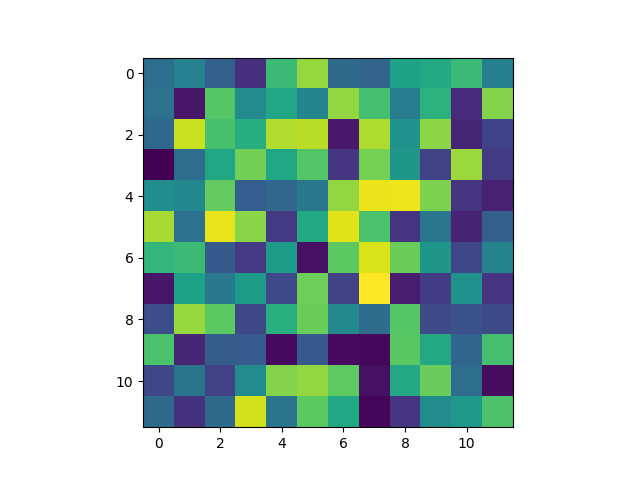

In [11]:
%matplotlib widget
# In case of issue with package installation, try:
#%matplotlib inline
import matplotlib.pyplot as plt

fig,ax = plt.subplots()
ax.imshow(my_image) ;

The parameter `cmap` (short for **colormap**) controls **how pixel values are mapped to colors**.  
It determines the color scale used to represent the numerical data of an image.
#### Common Colormaps

| Colormap name | Description |
|---------------|-------------|
| `gray` / `Greys` | Black-to-white grayscale (default for many images) |
| `viridis` | Perceptually uniform, good for scientific data |
| `plasma` | Bright purple-to-yellow gradient |
| `inferno` | Dark purple-to-yellow gradient (high contrast) |
| `magma` | Dark purple-to-orange gradient |
| `jet` | Classic rainbow colormap (not recommended for quantitative data) |
| `hot` | Black-red-yellow-white gradient (heatmap style) |


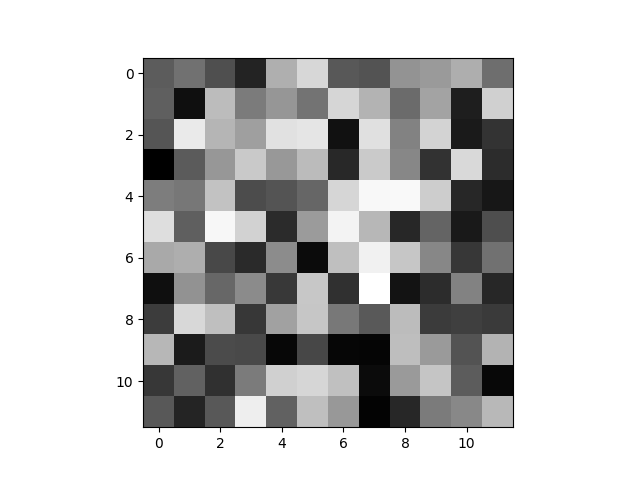

In [12]:
fig,ax = plt.subplots()
ax.imshow(my_image, cmap='gray');

#### 2-1-2- 2D numpy ara: 3 Channels

For color images, you usually have 3 channels:

- **R**: Red  
- **G**: Green  
- **B**: Blue  


Note that on some librarie, channels are coded as BGR.

Shape: (12, 12, 3)


(np.float64(-0.5), np.float64(11.5), np.float64(11.5), np.float64(-0.5))

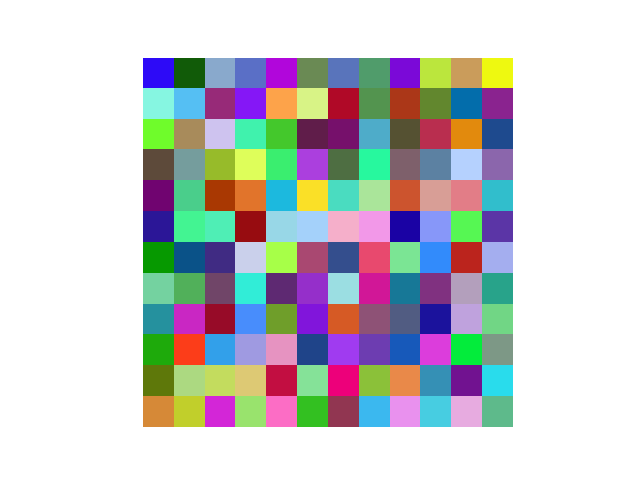

In [13]:
my_image_rgb = np.random.randint(0, 256, size=(12, 12, 3), dtype=np.uint8)
print("Shape:", my_image_rgb.shape)  
fig, ax = plt.subplots()
ax.imshow(my_image_rgb)
ax.axis('off')

#### 2-1-3- 2D numpy ara: 4 Channels

Sometimes a **4th channel** is added, called the **alpha channel**, which represents **transparency**.  
This is common in formats like **PNG**, where each pixel has RGBA values.


| Shape Example      | Meaning |
|-------------------|---------|
| `(height, width)` | Grayscale image (single channel) |
| `(height, width, 3)` | RGB image (3 channels: Red, Green, Blue) |
| `(height, width, 4)` | RGBA image (4 channels: Red, Green, Blue, Alpha = transparency) |


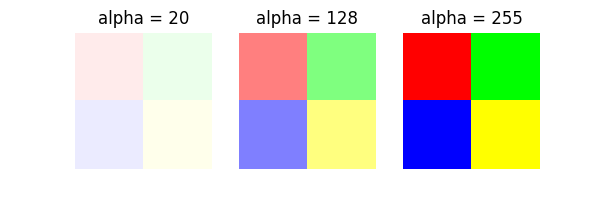

In [14]:
# 2x2 pixels, RGBA (R, G, B, A)

# Image 1 : alpha = transparency (very transparent)
transparency = 20
img_alpha_20 = np.array([
    [[255,   0,   0, transparency], [  0, 255,   0, transparency]],  # red    (255,0,0,transparency)   , green  (0,255,0,transparency)
    [[  0,   0, 255, transparency], [255, 255,   0, transparency]]   # blue   (0,0,255,transparency)  , yellow (255,255,0,transparency)
], dtype=np.uint8)

# Image 2 : alpha = transparency (half-transparent)
transparency = 128
img_alpha_128 = np.array([
    [[255,   0,   0, transparency], [  0, 255,   0, transparency]],  # red    (255,0,0,transparency)   , green  (0,255,0,transparency)
    [[  0,   0, 255, transparency], [255, 255,   0, transparency]]   # blue   (0,0,255,transparency)  , yellow (255,255,0,transparency)
], dtype=np.uint8)

# Image 3 : alpha = transparency (no transparency)
transparency = 255
img_alpha_255 = np.array([
    [[255,   0,   0, transparency], [  0, 255,   0, transparency]],  # red    (255,0,0,transparency)   , green  (0,255,0,transparency)
    [[  0,   0, 255, transparency], [255, 255,   0, transparency]]   # blue   (0,0,255,transparency)  , yellow (255,255,0,transparency)
], dtype=np.uint8)

fig, axes = plt.subplots(1, 3, figsize=(6, 2))

axes[0].imshow(img_alpha_20)
axes[0].set_title("alpha = 20")
axes[0].axis("off")

axes[1].imshow(img_alpha_128)
axes[1].set_title("alpha = 128")
axes[1].axis("off")

axes[2].imshow(img_alpha_255)
axes[2].set_title("alpha = 255")
axes[2].axis("off")


plt.show();

#### 2-1-4- 2D numpy arrays: Image stack

In addition to single images (2D for grayscale or 3D for RGB/RGBA), **NumPy arrays with 3 or more dimensions** can store **stacks of images**.  

This is common in:
- Deep learning datasets (batch of images)
- Time series of images (video frames)
- Multi-spectral imaging  

 We create a **stack of 6 random RGB images** with shape `(6, 12, 12, 3)`

Shape of image stack: (6, 12, 12, 3)


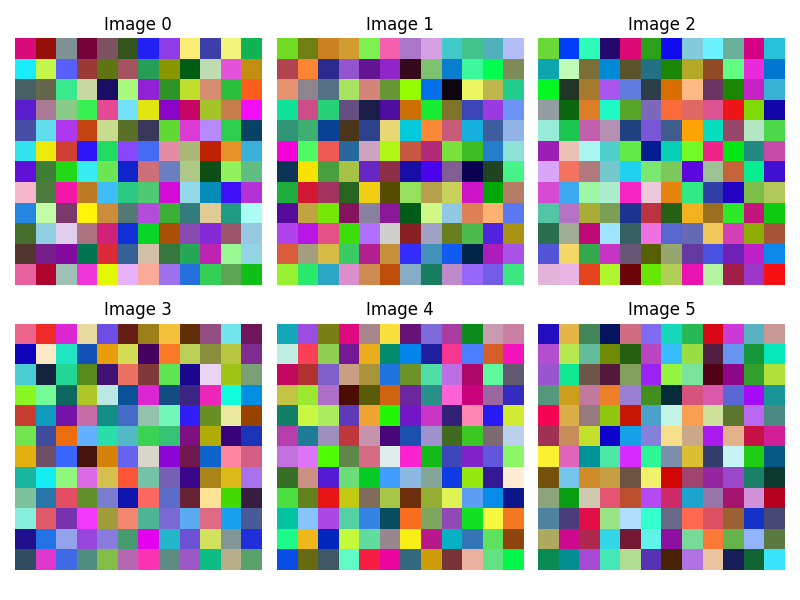

In [15]:
# Create a stack of 6 RGB images (12x12 pixels each)
image_stack = np.random.randint(0, 256, size=(6, 12, 12, 3), dtype=np.uint8)
print("Shape of image stack:", image_stack.shape)  # (6, 12, 12, 3)

# Plot each image in a 2×3 grid
fig, axes = plt.subplots(2, 3, figsize=(8, 6))
axes = axes.ravel()  # Flatten axes for easy iteration

for i in range(6):
    axes[i].imshow(image_stack[i])  # Show i-th image
    axes[i].set_title(f"Image {i}")
    axes[i].axis('off')

plt.tight_layout()
plt.show();


##### **Recap of NumPy array sizes for image data:**
| Shape Example        | Meaning |
|---------------------|---------|
| `(height, width)`   | Grayscale image (single channel, intensity only) |
| `(height, width, 3)` | RGB image (3 channels: Red, Green, Blue) |
| `(height, width, 4)` | RGBA image (4 channels: Red, Green, Blue, Alpha for transparency) |
| `(n_images, height, width)` | Stack of grayscale images (batch of images) |
| `(n_images, height, width, 3)` | Stack of RGB images |
| `(n_images, height, width, 4)` | Stack of RGBA images (with transparency) |

### 2-2- Open and save images
#### 2-2-1- Images with matplotlib

The function `matplotlib.pyplot.imread` reads an image from disk and returns it as a NumPy array.  
Each pixel is represented as numbers (for example, RGB values between 0 and 1 or 0 and 255 depending on the file type).  

(399, 847, 3)


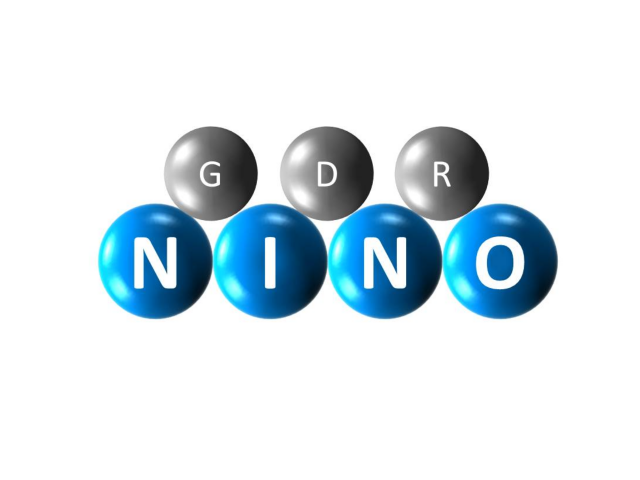

In [16]:
# Read image with matplotlib
#image = plt.imread('data/image1.jpg')
image = plt.imread('data/nino.jpg')
# Convert to numpy array
image = np.array(image)
print(image.shape)
fig,ax = plt.subplots()
ax.imshow(image)
ax.axis('off');

You can also **save images** back to disk using `matplotlib.pyplot.imsave`, which writes a NumPy array (image data) to a file in formats like PNG or JPEG.


In [17]:
# Create a random RGB image
my_image_rgb = np.random.randint(0, 256, size=(128, 128, 3), dtype=np.uint8)

# Save the image to disk as PNG
plt.imsave('data/my_image_rgb.png', my_image_rgb)

print("Image saved")

Image saved


Display multi channels image 

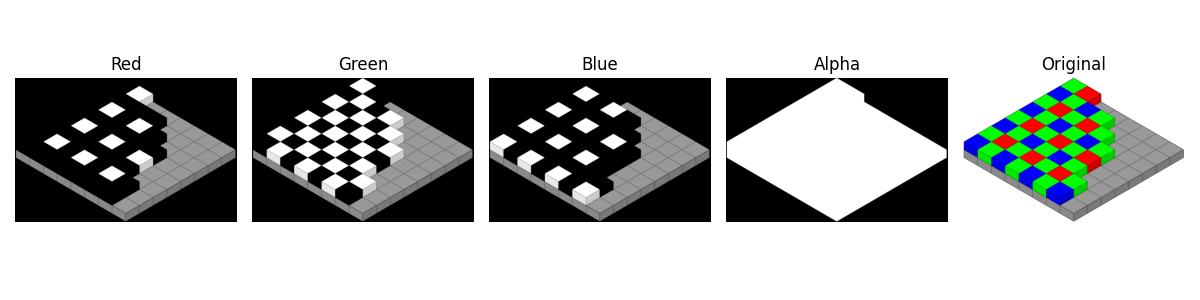

In [18]:
# representing RGBA (Red, Green, Blue, Alpha) channels.
# Example (random RGBA image):

image = plt.imread('data/rgb.png')
fig, axes = plt.subplots(1, 5, figsize=(12, 3))  # 1 row, 4 columns of subplots

channel_names = ['Red', 'Green', 'Blue', 'Alpha']

for i in range(4):
    # Show the i-th channel as a grayscale image
    axes[i].imshow(image[:, :, i], cmap='gray')
    axes[i].set_title(channel_names[i])  # Label the channel
    axes[i].axis('off')  # Remove axes for clarity

axes[4].imshow(image)
axes[4].set_title('Original')  # Label the channel
axes[4].axis('off')  # Remove axes for clarity

plt.tight_layout()
plt.show();

### 2-1 Python libraries for image

Python also offers several dedicated image-processing libraries.  
Each of them complements NumPy by adding higher-level functions for opening, manipulating, and saving images.


**Pillow (PIL)**  
Pillow is a friendly and easy-to-use library for opening, manipulating, and displaying images. It is often used for simple image processing tasks in scientific workflows.

**OpenCV (cv2)**  
OpenCV is a powerful library mainly used for computer vision tasks. It provides fast image display and processing capabilities, but note that `cv2.imshow` opens a separate window outside the notebook.

**scikit-image (skimage)**  
scikit-image is designed for scientific image processing. It integrates well with NumPy and Matplotlib, making it convenient for analysis and visualization of microscopy or experimental images.


#### 2-1-1- Open CV

A high-performance library widely used in **computer vision**.  
It excels at fast image I/O, transformations, and real-time processing.  
Note: `cv2.imshow` opens an external window (not inline in notebooks).  

[opencv documentation](https://docs.opencv.org/4.x/d6/d00/tutorial_py_root.html)

In [19]:
import cv2
image  = cv2.imread('data/nino.jpg')
cv2.imshow("My Image", image)
cv2.waitKey(0) 
cv2.destroyAllWindows()

-1

#### 2-1-2- Pillow (Pil)

A **simple and user-friendly** library for opening, manipulating, and displaying images.
It’s great for lightweight image tasks directly inside a notebook.   

[pil documentation](https://hugovk-pillow.readthedocs.io/en/stable/index.html)

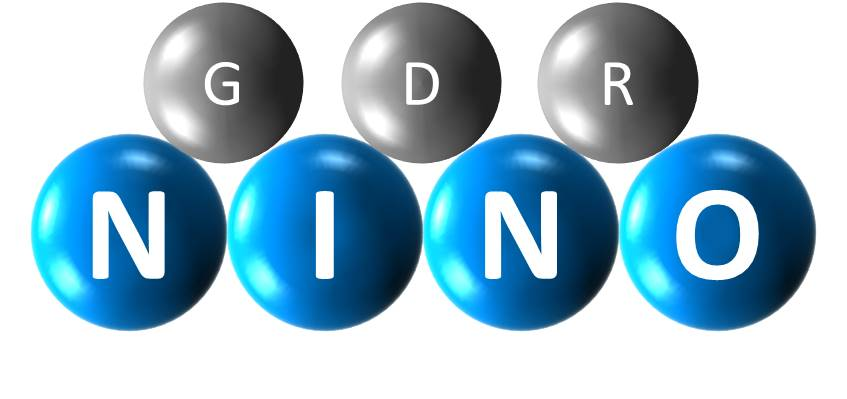

In [20]:
from PIL import Image
image = Image.open('data/nino.jpg')

#pil_img = Image.fromarray(image.astype(np.uint8))
display(image)  # affiche directement dans le notebook

#### 2-1-3 Scikit image

A **scientific image** processing library built on NumPy and Matplotlib.
It’s ideal for analysis and visualization of microscopy or experimental images.  

[scikit image documentation](https://scikit-image.org/docs/stable/)

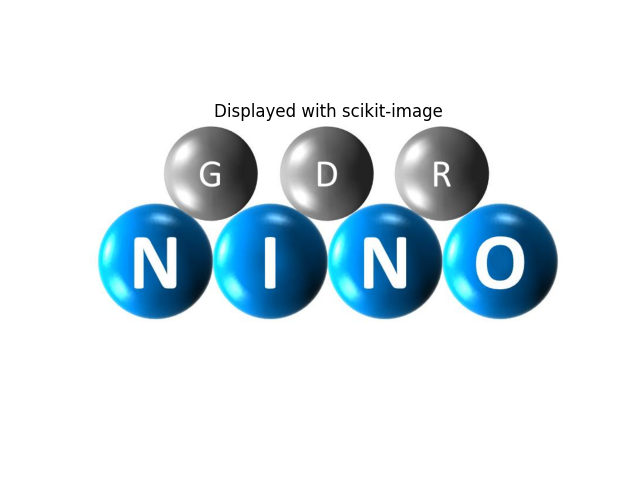

In [21]:
from skimage import io
import matplotlib.pyplot as plt

image = io.imread('data/nino.jpg')

plt.figure()  # crée une nouvelle figure vierge
plt.imshow(image)
plt.title("Displayed with scikit-image")
plt.axis('off')
plt.show();


## 3- Some examples in opencv

### 3-1- Thresholding and Contour Detection for Particle Analysis

In image processing, **thresholding** is often used to separate objects of interest from the background by converting an image to binary (black and white) based on pixel intensity.  

Once objects are isolated, **contour detection** can be applied to find the boundaries of each object.  

This combination is very useful for **particle analysis**, allowing us to:  
- **Count objects** in an image.  
- **Measure their size** (area, width, height, or approximate diameter).  
- Analyze distributions of particle sizes using histograms.  

Libraries like **OpenCV** provide efficient tools for thresholding (`cv2.threshold`) and contour detection (`cv2.findContours`), making this workflow straightforward in Python.


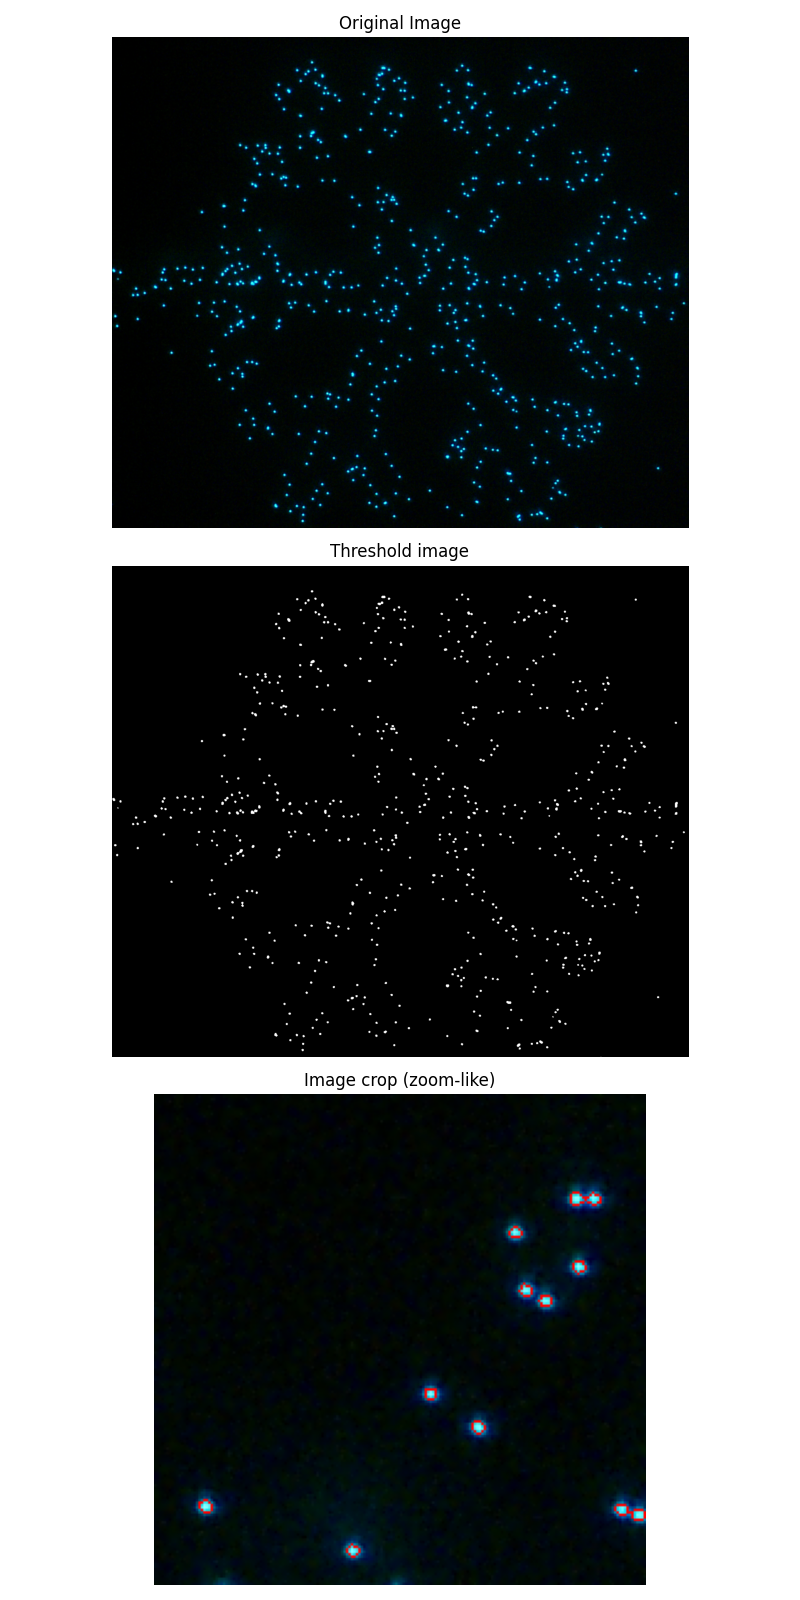

In [22]:
# --- Read the image ---
image = cv2.imread('data/fluo_latex_1.tif')

# --- Convert to grayscale ---
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

# --- Apply binary threshold ---
ret, threshold = cv2.threshold(gray, 100, 255, cv2.THRESH_BINARY)

# --- Find contours ---
contours, hierarchy = cv2.findContours(threshold, cv2.RETR_TREE, cv2.CHAIN_APPROX_SIMPLE)

# --- Draw contours on a copy of the original image ---
image_with_contours = image.copy()
for cnt in contours:
    cv2.drawContours(image_with_contours, [cnt], 0, (0, 0, 255), 1)  # Red contours

# --- Define crops using explicit slices ---

# crop_center   = image_with_contours[300:600, 600:900]   
crop_center   = image_with_contours[300:500, 700:900] 

# --- Display results in subplots (columns) ---
fig, axes = plt.subplots(3, 1, figsize=(8, 16))  # 3 rows, 1 column

# Original image
axes[0].imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
axes[0].set_title("Original Image")
axes[0].axis('off')

# threshold
axes[1].imshow(cv2.cvtColor(threshold, cv2.COLOR_BGR2RGB))
axes[1].set_title("Threshold image")
axes[1].axis('off')

# Center crop
axes[2].imshow(cv2.cvtColor(crop_center, cv2.COLOR_BGR2RGB))
axes[2].set_title("Image crop (zoom-like)")
axes[2].axis('off')

plt.tight_layout()
plt.show();



In [23]:
print(f"Number of contours detected: {len(contours)}")

Number of contours detected: 593


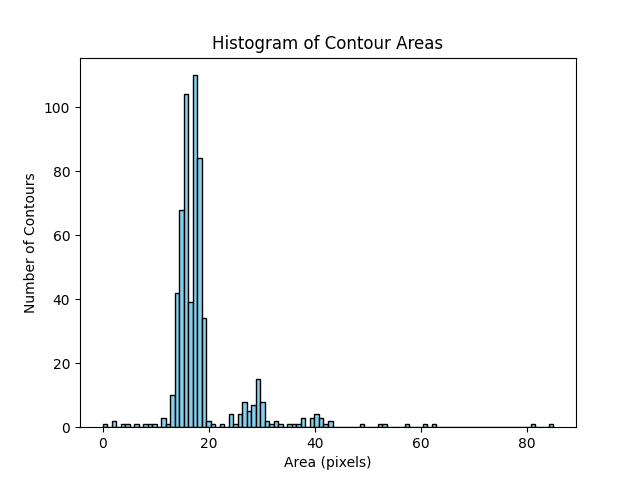

In [24]:
# --- Compute contour areas ---
contour_areas = [cv2.contourArea(cnt) for cnt in contours]
# Histogram of contour areas
fig, ax = plt.subplots()
ax.hist(contour_areas, bins=100, color='skyblue', edgecolor='black')
ax.set_title("Histogram of Contour Areas")
ax.set_xlabel("Area (pixels)")
ax.set_ylabel("Number of Contours");

## 3-2- Video

OpenCV allows you to **read and process videos frame by frame** in Python. This is useful for tasks such as video analysis, object tracking, or real-time image processing.

The basic workflow is:

1. **Load the video** using `cv2.VideoCapture(video_path)`.
2. **Loop through each frame**:
   - Read a frame with `cap.read()`.
   - Break the loop if the frame cannot be read.
   - Process or display the frame (e.g., convert to grayscale or show it in a window).
3. **Exit the loop** when a specific key is pressed (e.g., 'q').
4. **Release the video capture** and close all OpenCV windows with `cap.release()` and `cv2.destroyAllWindows()`.


In [25]:
# Path to the video
#video_path = "data/ma_video.mp4"
video_path = "data/in_situ_TEM_Ni_deposition.mp4"

# Load the video
cap = cv2.VideoCapture(video_path)

# Loop to read each frame of the video
while True:
    # Read a frame
    ret, frame = cap.read()
    # Exit the loop if the frame is not read correctly
    if not ret:
        break 
    # Display the frame in grayscale
    cv2.imshow('in situ TEM Ni deposition', frame)  
    # Wait for 'q' key to exit the loop
    if cv2.waitKey(25) & 0xFF == ord('q'):
        break

# Release the video capture
cap.release()
# Close all windows
cv2.destroyAllWindows()


Just like with individual images, you can apply **image processing operations** to each frame of a video. For example, you can perform segmentation using .

Below is an example that **threshold video** of in situ TEM of Ni deposition. 

In [26]:
video_path = "data/in_situ_TEM_Ni_deposition.mp4"
cap = cv2.VideoCapture(video_path)

while True:
    # Read a frame from the video
    ret, frame = cap.read()

    # Stop if the video has ended
    if not ret:
        break

    # Convert the frame to grayscale
    frame_gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)

    # Apply binary threshold at 140
    _, thresh = cv2.threshold(frame_gray, 160, 255, cv2.THRESH_BINARY)

    # Display the thresholded frame
    cv2.imshow("Binary Threshold (140)", thresh)

    # Wait 25 ms and allow exit with 'q'
    if cv2.waitKey(25) & 0xFF == ord('q'):
        break

# Release resources
cap.release()
cv2.destroyAllWindows()


From the previous code we can from example extract the ration of black pixel/white pixels.

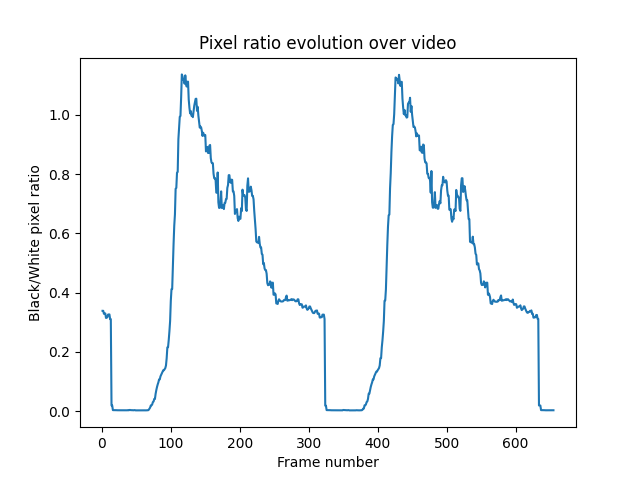

In [27]:
video_path = "data/in_situ_TEM_Ni_deposition.mp4"
cap = cv2.VideoCapture(video_path)

ratios = []
frame_numbers = []

frame_id = 0

while True:
    ret, frame = cap.read()
    if not ret:
        break

    frame_id += 1

    # Convert to grayscale
    frame_gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)

    # Apply binary threshold at 140
    _, thresh = cv2.threshold(frame_gray, 160, 255, cv2.THRESH_BINARY)

    # Count black and white pixels
    nb_white = cv2.countNonZero(thresh)
    nb_total = thresh.size
    nb_black = nb_total - nb_white

    # Avoid division by zero
    ratio = nb_black / nb_white if nb_white > 0 else 0

    ratios.append(ratio)
    frame_numbers.append(frame_id)

cap.release()

# Plot ratio vs frame number
fig,ax = plt.subplots()
ax.plot(frame_numbers, ratios)
ax.set_xlabel("Frame number")
ax.set_ylabel("Black/White pixel ratio")
ax.set_title("Pixel ratio evolution over video")
plt.show();


## Next Steps: Applying the Basics to a Real Problem

Now that we have covered the fundamentals of image manipulation, visualization, and basic processing in Python, we will apply these skills to a concrete problem: **preparing a dataset for training an AI model** using synchrotron image data.  

In the next notebook, you will see how to handle real experimental images, perform preprocessing, and structure the data for machine learning workflows.

[Open the notebook to start working with the synchrotron dataset](image_processing_workshop.ipynb)  


In [28]:
vID.end(cwd0)

**End at:** Tuesday 30 September 2025, 09:48:38  
**Duration:** 00:00:39 322ms

<p style="text-align: center"><img width="800px" src="./config/svg/logoEnd.svg" style="margin-left:auto; margin-right:auto"/></p>